In [3]:
library(Seurat)
library(ggplot2)

## (1) Tomeas T,et al.

In [2]:
sce=readRDS('/home/lixinxing/IBD/publicdata/Data1/public_T_anno.rds')
table(sce$subtype)


      CD4+ CTLs   CD4+ T Prolif         CD4+ Tn       CD4+ Treg  CD4+ Trm/Temra 
          12191               8           11916            9965           29674 
       CD8+ IEL       CD8+ MAIT    CD8+ T_Metab  CD8+ T_Muc_Inf  CD8+ Tem/Temra 
           1370             844              90            3104            9945 
        CD8+ Tn   CD8+ Trm/MAIT CD8+ γδ T/Tregs       IL10+ DNT   NELL2+CD4+ Tn 
           1778           17744            1623              51            5901 
            Tfh 
           1644 

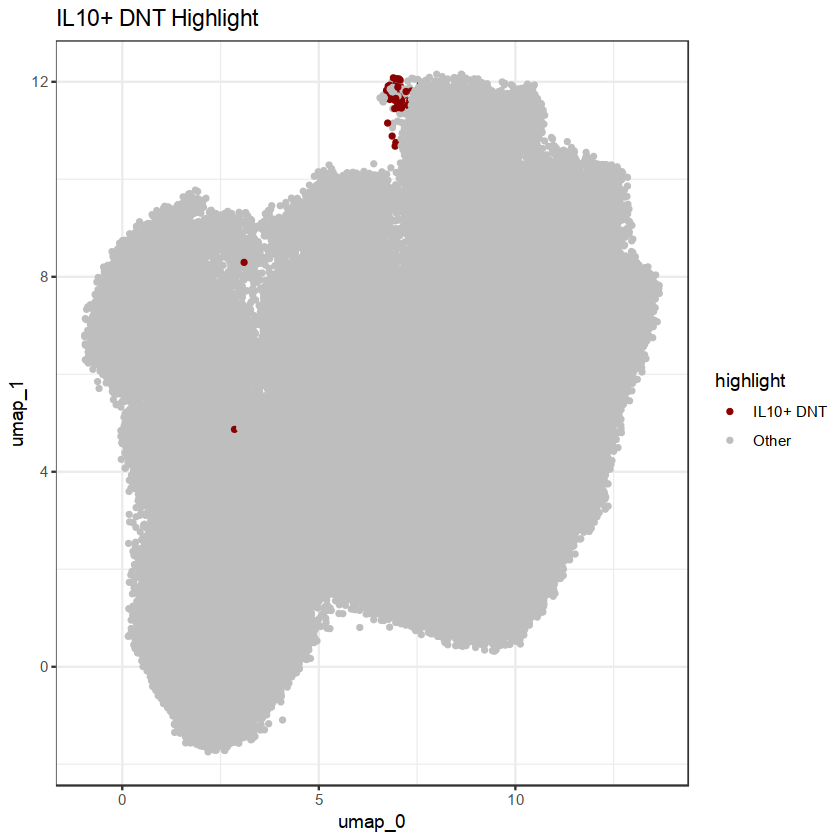

In [ ]:
df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")

ggplot(df, aes(x = umap_0, y = umap_1)) +
  geom_point(aes(color = highlight), size = 1, alpha = 1) +
  scale_color_manual(values = c("IL10+ DNT" = "darkred", "Other" = "grey")) +
  theme_bw() +
  ggtitle("IL10+ DNT Highlight")

# ggsave("umap_cd4_manual.pdf", width = 10, height = 8)


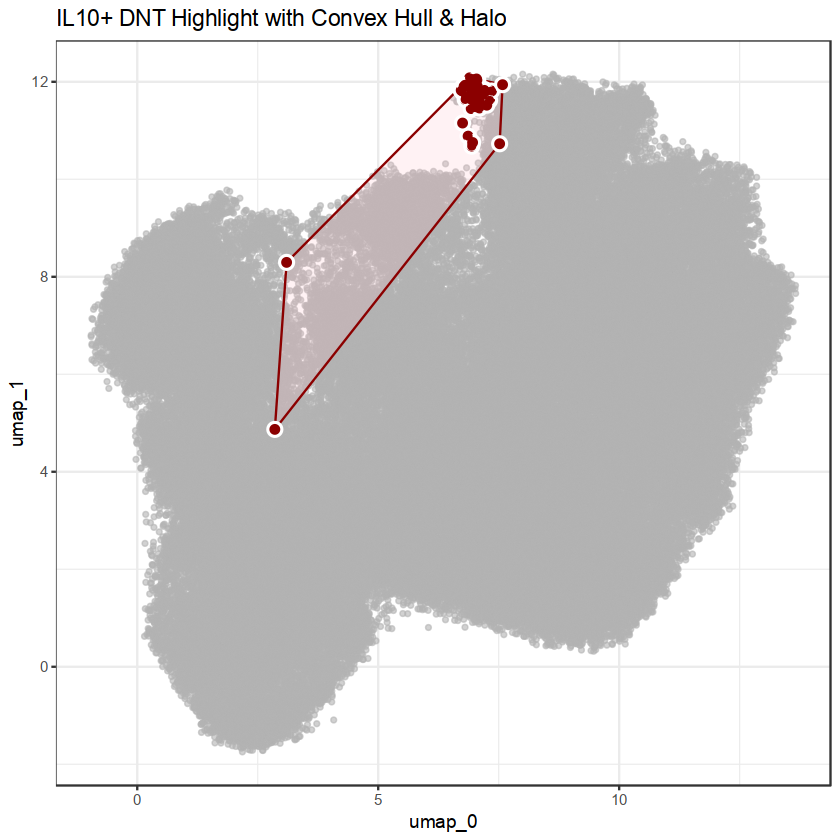

In [24]:
df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")
df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")

hull_idx <- chull(df_dnt[, c("umap_0","umap_1")])
hull_df  <- df_dnt[hull_idx, ]

p <- ggplot() +
  geom_point(data  = df_other,aes(x = umap_0, y = umap_1),color = "grey70",size  = 1,alpha = 0.6) +
  geom_polygon(data    = hull_df,aes(x = umap_0, y = umap_1),fill    = "pink",alpha   = 0.2,color   = "darkred",size    = 0.5) +
  geom_point(
    data   = df_dnt,
    aes(x = umap_0, y = umap_1),
    shape  = 21,
    fill   = "darkred",
    color  = "white",
    size   = 3,
    stroke = 1
  ) +
  geom_point(
    data  = df_dnt,
    aes(x = umap_0, y = umap_1),
    color = "darkred",
    size  = 1.5
  ) +
  theme_bw() +
  ggtitle("IL10+ DNT Highlight with Convex Hull & Halo") +
  theme(legend.position="none")

print(p)


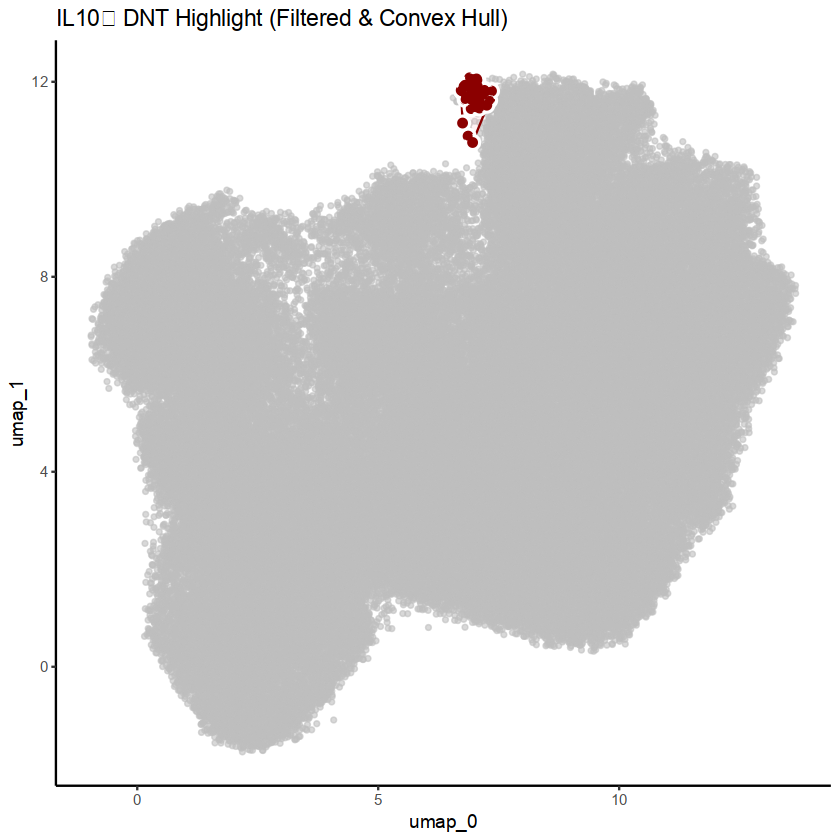

In [25]:
df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")

df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")


centroid <- colMeans(df_dnt[, c("umap_0","umap_1")])
df_dnt$dist <- sqrt((df_dnt$umap_0 - centroid[1])^2 +
                    (df_dnt$umap_1 - centroid[2])^2)

thresh    <- quantile(df_dnt$dist, 0.90)
df_dnt_in <- df_dnt[df_dnt$dist <= thresh, ]

hull_idx <- chull(df_dnt_in[, c("umap_0","umap_1")])
hull_df  <- df_dnt_in[hull_idx, ]

p <- ggplot() +
  geom_point(
    data  = df_other,
    aes(x = umap_0, y = umap_1),
    color = "grey", size = 1, alpha = 0.6
  ) +
  geom_polygon(
    data  = hull_df,
    aes(x = umap_0, y = umap_1),
    fill  = "pink", alpha = 0.2,
    color = "darkred", size = 0.5
  ) +
  geom_point(
    data   = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    shape  = 21, fill = "darkred", color = "white",
    size   = 3, stroke = 1
  ) +
  geom_point(
    data  = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    color = "darkred", size = 1.5
  ) +
  theme_classic() +
  ggtitle("IL10⁺ DNT Highlight (Filtered & Convex Hull)") +
  theme(legend.position = "none")

print(p)
ggsave(p,file='/home/lixinxing/IBD/Fig_new_2/Fig1/public_T_1.pdf',width = 6,height = 6,device = cairo_pdf)

## (2) Kong L, et al.(2025)

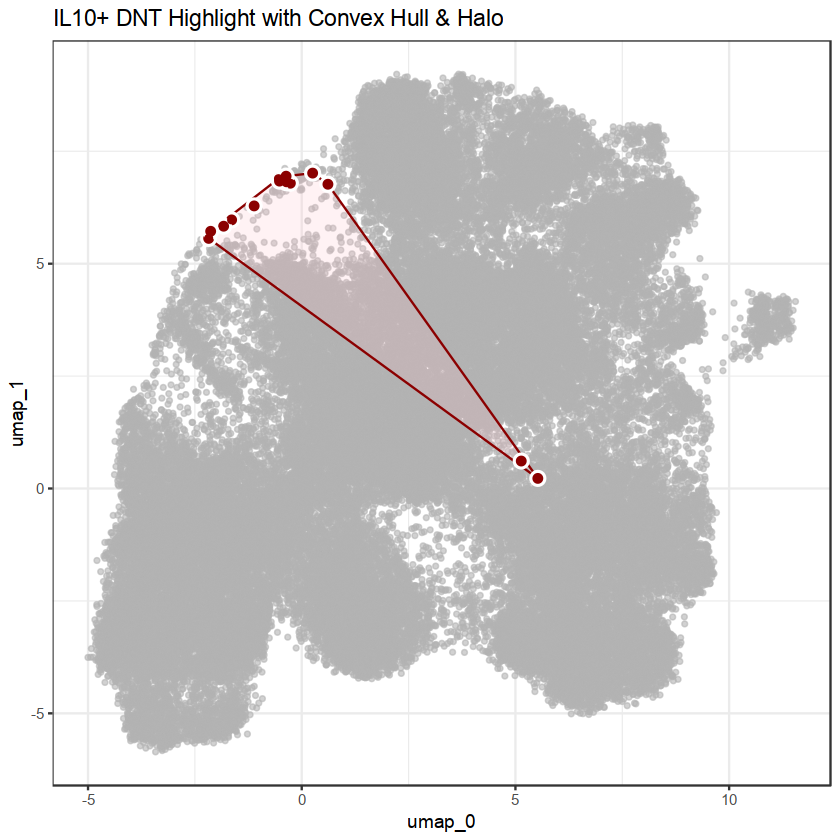

In [20]:
# sce=readRDS('./adata_ref.rds')
sce=readRDS('/home/lixinxing/IBD/publicdata/2025_07_18/Data2/T_public_2_ano.rds')

df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")
df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")

hull_idx <- chull(df_dnt[, c("umap_0","umap_1")])
hull_df  <- df_dnt[hull_idx, ]

p <- ggplot() +
  geom_point(data  = df_other,aes(x = umap_0, y = umap_1),color = "grey70",size  = 1,alpha = 0.6) +
  geom_polygon(data    = hull_df,aes(x = umap_0, y = umap_1),fill    = "pink",alpha   = 0.2,color   = "darkred",size    = 0.5) +
  geom_point(
    data   = df_dnt,
    aes(x = umap_0, y = umap_1),
    shape  = 21,
    fill   = "darkred",
    color  = "white",
    size   = 3,
    stroke = 1
  ) +
  geom_point(
    data  = df_dnt,
    aes(x = umap_0, y = umap_1),
    color = "darkred",
    size  = 1.5
  ) +
  theme_bw() +
  ggtitle("IL10+ DNT Highlight with Convex Hull & Halo") +
  theme(legend.position="none")

print(p)


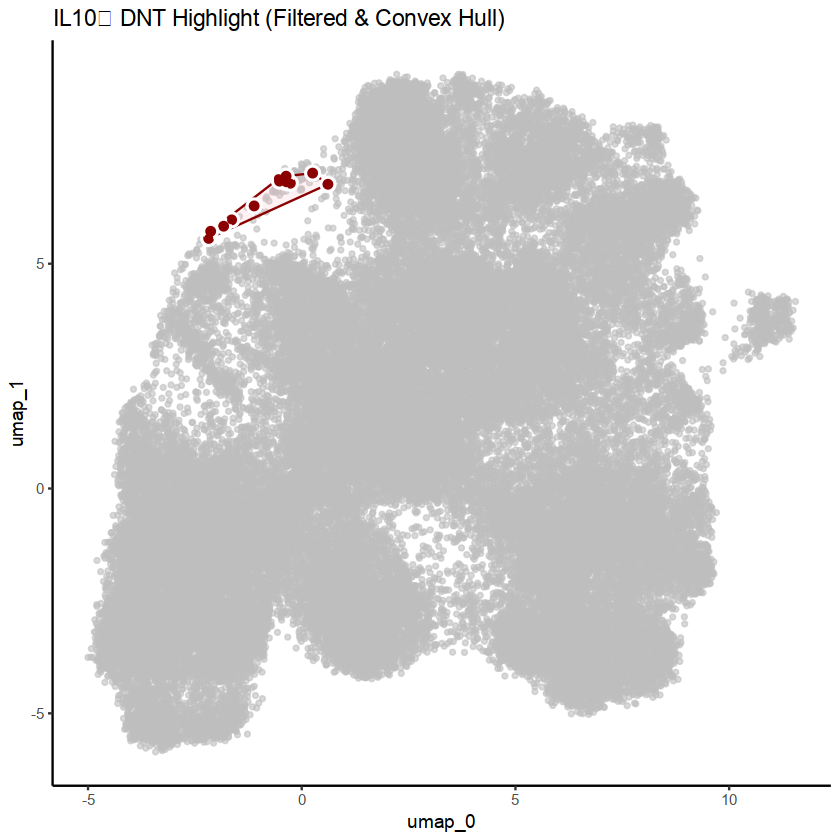

In [21]:
df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")

df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")


centroid <- colMeans(df_dnt[, c("umap_0","umap_1")])
df_dnt$dist <- sqrt((df_dnt$umap_0 - centroid[1])^2 +
                    (df_dnt$umap_1 - centroid[2])^2)

thresh    <- quantile(df_dnt$dist, 0.90)
df_dnt_in <- df_dnt[df_dnt$dist <= thresh, ]

hull_idx <- chull(df_dnt_in[, c("umap_0","umap_1")])
hull_df  <- df_dnt_in[hull_idx, ]

p <- ggplot() +
  geom_point(
    data  = df_other,
    aes(x = umap_0, y = umap_1),
    color = "grey", size = 1, alpha = 0.6
  ) +
  geom_polygon(
    data  = hull_df,
    aes(x = umap_0, y = umap_1),
    fill  = "pink", alpha = 0.2,
    color = "darkred", size = 0.5
  ) +
  geom_point(
    data   = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    shape  = 21, fill = "darkred", color = "white",
    size   = 3, stroke = 1
  ) +
  geom_point(
    data  = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    color = "darkred", size = 1.5
  ) +
  theme_classic() +
  ggtitle("IL10⁺ DNT Highlight (Filtered & Convex Hull)") +
  theme(legend.position = "none")

print(p)
ggsave(p,file='/home/lixinxing/IBD/Fig_new_2/Fig1/public_T_2.pdf',width = 6,height = 6,device = cairo_pdf)

## (3) Kong L, et al.(2023)

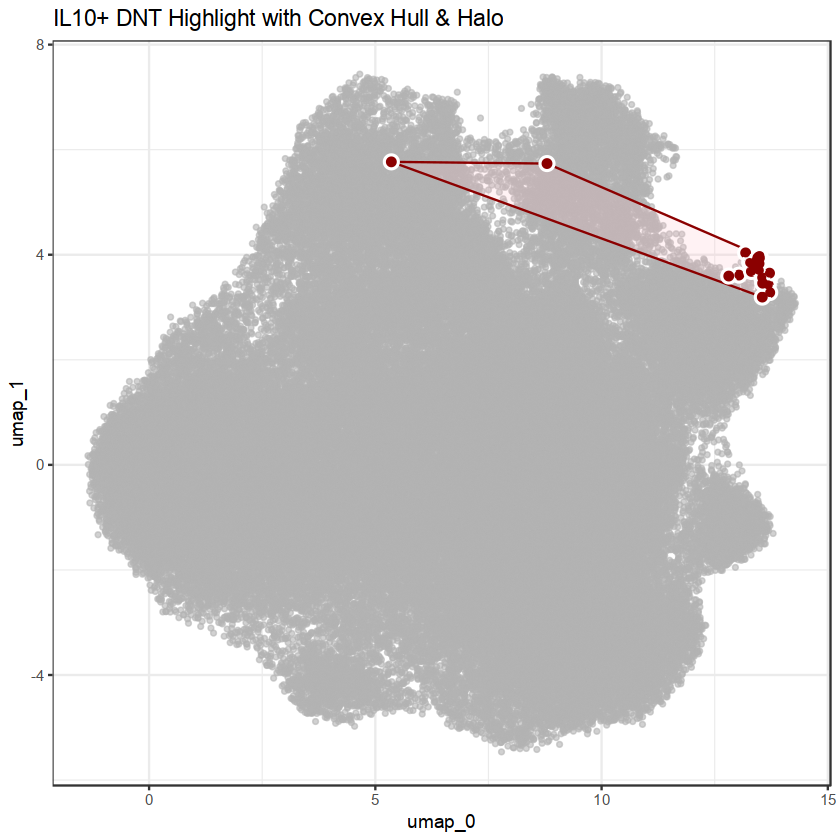

In [13]:
# sce=readRDS('./adata_ref.rds')
sce=readRDS('/home/lixinxing/IBD/publicdata/2025_07_18/Data4/T_public_4_ano.rds')

df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")
df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")

hull_idx <- chull(df_dnt[, c("umap_0","umap_1")])
hull_df  <- df_dnt[hull_idx, ]

p <- ggplot() +
  geom_point(data  = df_other,aes(x = umap_0, y = umap_1),color = "grey70",size  = 1,alpha = 0.6) +
  geom_polygon(data    = hull_df,aes(x = umap_0, y = umap_1),fill    = "pink",alpha   = 0.2,color   = "darkred",size    = 0.5) +
  geom_point(
    data   = df_dnt,
    aes(x = umap_0, y = umap_1),
    shape  = 21,
    fill   = "darkred",
    color  = "white",
    size   = 3,
    stroke = 1
  ) +
  geom_point(
    data  = df_dnt,
    aes(x = umap_0, y = umap_1),
    color = "darkred",
    size  = 1.5
  ) +
  theme_bw() +
  ggtitle("IL10+ DNT Highlight with Convex Hull & Halo") +
  theme(legend.position="none")

print(p)


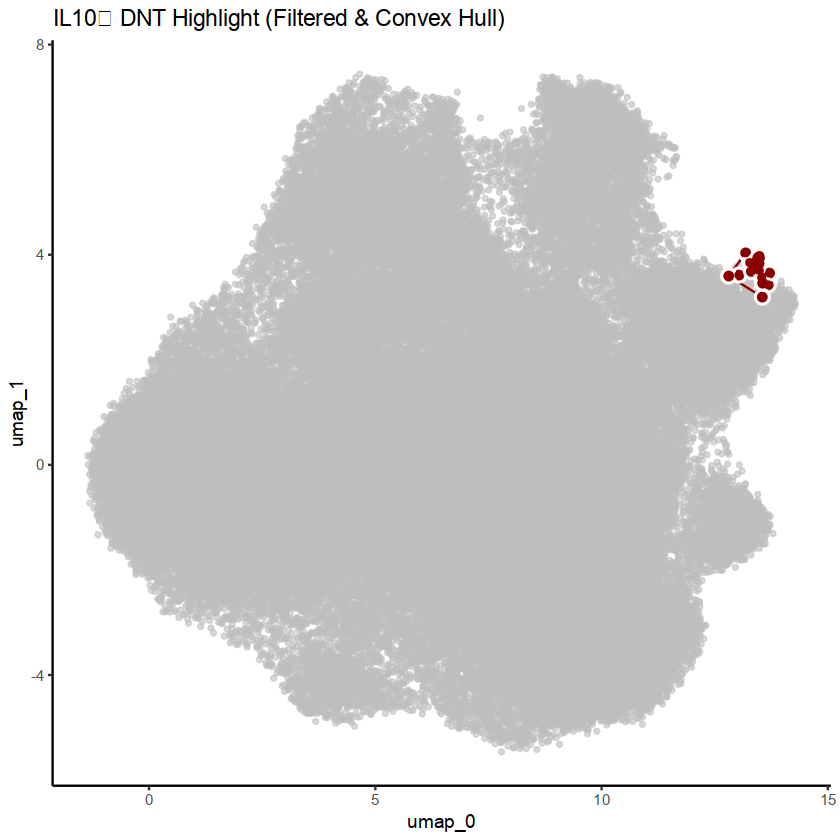

In [17]:
df <- as.data.frame(Embeddings(sce, "umap"))
df$celltype <- sce$subtype
df$highlight <- ifelse(df$celltype == "IL10+ DNT", "IL10+ DNT", "Other")

df_other <- subset(df, highlight == "Other")
df_dnt   <- subset(df, highlight == "IL10+ DNT")


centroid <- colMeans(df_dnt[, c("umap_0","umap_1")])
df_dnt$dist <- sqrt((df_dnt$umap_0 - centroid[1])^2 +
                    (df_dnt$umap_1 - centroid[2])^2)

thresh    <- quantile(df_dnt$dist, 0.90)
df_dnt_in <- df_dnt[df_dnt$dist <= thresh, ]

hull_idx <- chull(df_dnt_in[, c("umap_0","umap_1")])
hull_df  <- df_dnt_in[hull_idx, ]

p <- ggplot() +
  geom_point(
    data  = df_other,
    aes(x = umap_0, y = umap_1),
    color = "grey", size = 1, alpha = 0.6
  ) +
  geom_polygon(
    data  = hull_df,
    aes(x = umap_0, y = umap_1),
    fill  = "pink", alpha = 0.2,
    color = "darkred", size = 0.5
  ) +
  geom_point(
    data   = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    shape  = 21, fill = "darkred", color = "white",
    size   = 3, stroke = 1
  ) +
  geom_point(
    data  = df_dnt_in,
    aes(x = umap_0, y = umap_1),
    color = "darkred", size = 1.5
  ) +
  theme_classic() +
  ggtitle("IL10⁺ DNT Highlight (Filtered & Convex Hull)") +
  theme(legend.position = "none")

print(p)
ggsave(p,file='/home/lixinxing/IBD/Fig_new_2/Fig1/public_T_4.pdf',width = 6,height = 6,device = cairo_pdf)